In [1]:
# STEP 1 — Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

print("Drive mounted successfully.")

Mounted at /content/drive
Drive mounted successfully.


In [2]:
!kaggle datasets download -d aryansraut/preprocessed-ucf-crime-dataset-visual -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/aryansraut/preprocessed-ucf-crime-dataset-visual
License(s): apache-2.0
100% 1.04G/1.04G [00:10<00:00, 111MB/s] 



In [3]:
import os

base = "/content"

for item in os.listdir(base):
    print(item)

.config
TikHarm_frames_16
drive
sample_data


In [4]:
import os

base = "/content/TikHarm_frames_16"

print("Exists:", os.path.exists(base))
print("\nTop folders/files:")
for item in os.listdir(base):
    print(item)

Exists: True

Top folders/files:
train
test
val


In [5]:
import os

for split in ["train", "val", "test"]:
    split_path = f"/content/TikHarm_frames_16/{split}"
    print(f"\n{split.upper()}:")
    classes = os.listdir(split_path)
    print("Number of classes:", len(classes))
    print("Classes:", classes)


TRAIN:
Number of classes: 4
Classes: ['Adult Content', 'Harmful Content', 'Suicide', 'Safe']

VAL:
Number of classes: 4
Classes: ['Adult Content', 'Harmful Content', 'Suicide', 'Safe']

TEST:
Number of classes: 4
Classes: ['Adult Content', 'Harmful Content', 'Suicide', 'Safe']


In [6]:
import os

base = "/content/TikHarm_frames_16"

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}:")
    split_path = os.path.join(base, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        count = len(os.listdir(cls_path))
        print(f"{cls}: {count}")


TRAIN:
Adult Content: 684
Harmful Content: 693
Suicide: 687
Safe: 698

VAL:
Adult Content: 98
Harmful Content: 99
Suicide: 100
Safe: 99

TEST:
Adult Content: 195
Harmful Content: 198
Suicide: 197
Safe: 200


In [7]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4


Adult Content -> size: (224, 224), mode: RGB


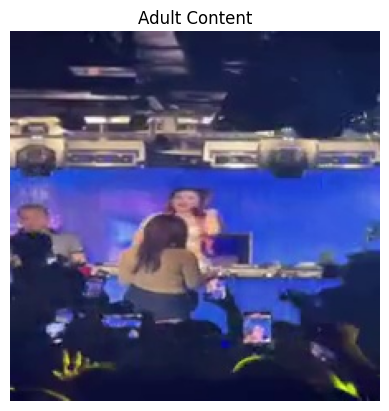

Harmful Content -> size: (224, 224), mode: RGB


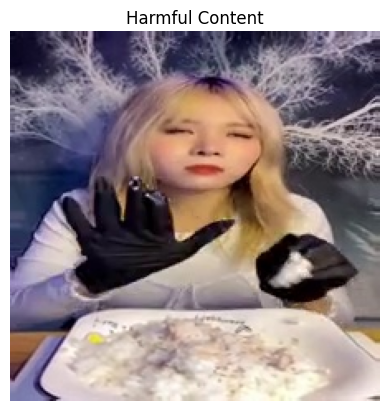

Suicide -> size: (224, 224), mode: RGB


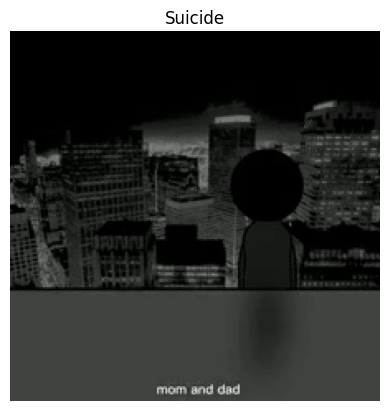

Safe -> size: (224, 224), mode: RGB


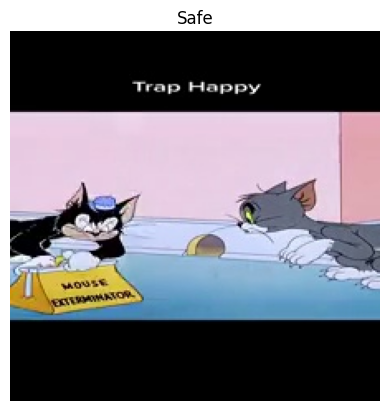

In [8]:
import os
from PIL import Image
import matplotlib.pyplot as plt

base = "/content/TikHarm_frames_16/train"

for cls in os.listdir(base):
    cls_path = os.path.join(base, cls)

    subfolder = os.listdir(cls_path)[0]
    subfolder_path = os.path.join(cls_path, subfolder)

    img_name = os.listdir(subfolder_path)[0]
    img_path = os.path.join(subfolder_path, img_name)

    img = Image.open(img_path)
    print(f"{cls} -> size: {img.size}, mode: {img.mode}")

    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()

In [9]:
import os

base = "/content/TikHarm_frames_16/train"

for cls in os.listdir(base):
    cls_path = os.path.join(base, cls)
    first_video_folder = os.listdir(cls_path)[0]
    first_video_path = os.path.join(cls_path, first_video_folder)
    frame_count = len(os.listdir(first_video_path))
    print(f"{cls}: first sample folder = {first_video_folder}, number of frames = {frame_count}")

Adult Content: first sample folder = ellyhuong5999_7326270376487521537, number of frames = 16
Harmful Content: first sample folder = muoitoday_7081219859111087387, number of frames = 16
Suicide: first sample folder = teddyyyyyy27_7152499235940830491, number of frames = 16
Safe: first sample folder = poox.noon_7230297201560276270, number of frames = 16


In [10]:
import os

save_base = "/content/drive/MyDrive/GM_Assignment2_TikHarm"
folders = [
    save_base,
    f"{save_base}/checkpoints",
    f"{save_base}/best_model",
    f"{save_base}/outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Created:")
for folder in folders:
    print(folder)

Created:
/content/drive/MyDrive/GM_Assignment2_TikHarm
/content/drive/MyDrive/GM_Assignment2_TikHarm/checkpoints
/content/drive/MyDrive/GM_Assignment2_TikHarm/best_model
/content/drive/MyDrive/GM_Assignment2_TikHarm/outputs


In [11]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image

class TikHarmFrameDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_path = os.path.join(root_dir, cls_name)
            for video_folder in os.listdir(cls_path):
                video_path = os.path.join(cls_path, video_folder)
                self.samples.append((video_path, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        frame_names = sorted(os.listdir(video_path))
        frames = []

        for frame_name in frame_names:
            frame_path = os.path.join(video_path, frame_name)
            img = Image.open(frame_path).convert("RGB")
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        frames = torch.stack(frames)   # shape: [16, C, H, W]
        return frames, label

print("Dataset class ready")

Dataset class ready


In [12]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = TikHarmFrameDataset(
    root_dir="/content/TikHarm_frames_16/train",
    transform=transform
)

val_dataset = TikHarmFrameDataset(
    root_dir="/content/TikHarm_frames_16/val",
    transform=transform
)

test_dataset = TikHarmFrameDataset(
    root_dir="/content/TikHarm_frames_16/test",
    transform=transform
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", train_dataset.class_names)

Train samples: 2762
Val samples: 396
Test samples: 790
Classes: ['Adult Content', 'Harmful Content', 'Safe', 'Suicide']


In [13]:
sample_frames, sample_label = train_dataset[0]

print("Frames shape:", sample_frames.shape)
print("Label index:", sample_label)
print("Class name:", train_dataset.class_names[sample_label])

Frames shape: torch.Size([16, 3, 224, 224])
Label index: 0
Class name: Adult Content


In [14]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders ready")

DataLoaders ready


In [15]:
batch_frames, batch_labels = next(iter(train_loader))

print("Batch frames shape:", batch_frames.shape)
print("Batch labels shape:", batch_labels.shape)
print("Batch labels:", batch_labels)

Batch frames shape: torch.Size([4, 16, 3, 224, 224])
Batch labels shape: torch.Size([4])
Batch labels: tensor([3, 1, 1, 3])


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(train_dataset.class_names)

print("Device:", device)
print("Number of classes:", NUM_CLASSES)
print("Class names:", train_dataset.class_names)

Device: cuda
Number of classes: 4
Class names: ['Adult Content', 'Harmful Content', 'Safe', 'Suicide']


In [17]:
from transformers import VideoMAEForVideoClassification

model_name = "MCG-NJU/videomae-base"
model = VideoMAEForVideoClassification.from_pretrained(
    model_name,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

model = model.to(device)

print("Model loaded:", model_name)
print("Classifier output classes:", model.classifier.out_features)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/377M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/184 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.query.weight | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.bias            | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.key.weight   | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.bias          | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.v_bias       | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.weight        | UNEXPECT

Model loaded: MCG-NJU/videomae-base
Classifier output classes: 4


In [18]:
pixel_values = batch_frames.to(device)   # already [B, T, C, H, W]
labels = batch_labels.to(device)

with torch.no_grad():
    outputs = model(pixel_values=pixel_values, labels=labels)

print("Input shape:", pixel_values.shape)
print("Logits shape:", outputs.logits.shape)
print("Loss:", outputs.loss.item())

Input shape: torch.Size([4, 16, 3, 224, 224])
Logits shape: torch.Size([4, 4])
Loss: 1.4133254289627075


In [19]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

print("Loss function and optimizer ready")

Loss function and optimizer ready


In [20]:
SAVE_DIR = "/content/drive/MyDrive/GM_Assignment2_TikHarm"
BEST_MODEL_PATH = f"{SAVE_DIR}/best_model/videomae_best.pth"
CHECKPOINT_PATH = f"{SAVE_DIR}/checkpoints/videomae_last.pth"

print("Best model path:", BEST_MODEL_PATH)
print("Checkpoint path:", CHECKPOINT_PATH)

Best model path: /content/drive/MyDrive/GM_Assignment2_TikHarm/best_model/videomae_best.pth
Checkpoint path: /content/drive/MyDrive/GM_Assignment2_TikHarm/checkpoints/videomae_last.pth


In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for frames, labels in loader:
        frames = frames.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=frames).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print("train_one_epoch function ready")

train_one_epoch function ready


In [22]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for frames, labels in loader:
            frames = frames.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=frames).logits
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = total_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print("validate_one_epoch function ready")

validate_one_epoch function ready


In [23]:
EPOCHS = 3
best_val_acc = 0.0

print("EPOCHS:", EPOCHS)
print("Initial best_val_acc:", best_val_acc)

EPOCHS: 3
Initial best_val_acc: 0.0


In [24]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("History dictionary ready")

History dictionary ready


In [25]:
# Cell 26: final training loop + saving + early stopping + epoch-wise metrics

import torch

EPOCHS = 15
PATIENCE = 3
best_val_acc = 0.0
epochs_no_improve = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Accuracy: {val_acc:.4f}")

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history
    }, CHECKPOINT_PATH)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Best model saved")
    else:
        epochs_no_improve += 1
        print(f"No improvement: {epochs_no_improve}/{PATIENCE}")

    if epochs_no_improve >= PATIENCE:
        print("Early stopping triggered")
        break

print("\nTraining complete")
print("Best Val Accuracy:", best_val_acc)


Epoch 1/15
Train Loss: 1.1228 | Train Accuracy: 0.5087
Val   Loss: 1.0539 | Val   Accuracy: 0.5581
Best model saved

Epoch 2/15
Train Loss: 0.8885 | Train Accuracy: 0.6347
Val   Loss: 0.8609 | Val   Accuracy: 0.6692
Best model saved

Epoch 3/15
Train Loss: 0.7302 | Train Accuracy: 0.7075
Val   Loss: 0.8368 | Val   Accuracy: 0.6742
Best model saved

Epoch 4/15
Train Loss: 0.6045 | Train Accuracy: 0.7694
Val   Loss: 0.7748 | Val   Accuracy: 0.7045
Best model saved

Epoch 5/15
Train Loss: 0.4830 | Train Accuracy: 0.8175
Val   Loss: 0.8975 | Val   Accuracy: 0.6692
No improvement: 1/3

Epoch 6/15
Train Loss: 0.3669 | Train Accuracy: 0.8700
Val   Loss: 0.8225 | Val   Accuracy: 0.7273
Best model saved

Epoch 7/15
Train Loss: 0.3080 | Train Accuracy: 0.8867
Val   Loss: 0.9380 | Val   Accuracy: 0.6667
No improvement: 1/3

Epoch 8/15
Train Loss: 0.2598 | Train Accuracy: 0.9080
Val   Loss: 1.1902 | Val   Accuracy: 0.6641
No improvement: 2/3

Epoch 9/15
Train Loss: 0.1863 | Train Accuracy: 0.9366

In [26]:
# Cell 27: load best VideoMAE model and evaluate on test set

import torch

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

test_loss, test_acc = validate_one_epoch(model, test_loader, criterion, device)

print("Best model loaded from:", BEST_MODEL_PATH)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Best model loaded from: /content/drive/MyDrive/GM_Assignment2_TikHarm/best_model/videomae_best.pth
Test Loss: 0.8391
Test Accuracy: 0.7165


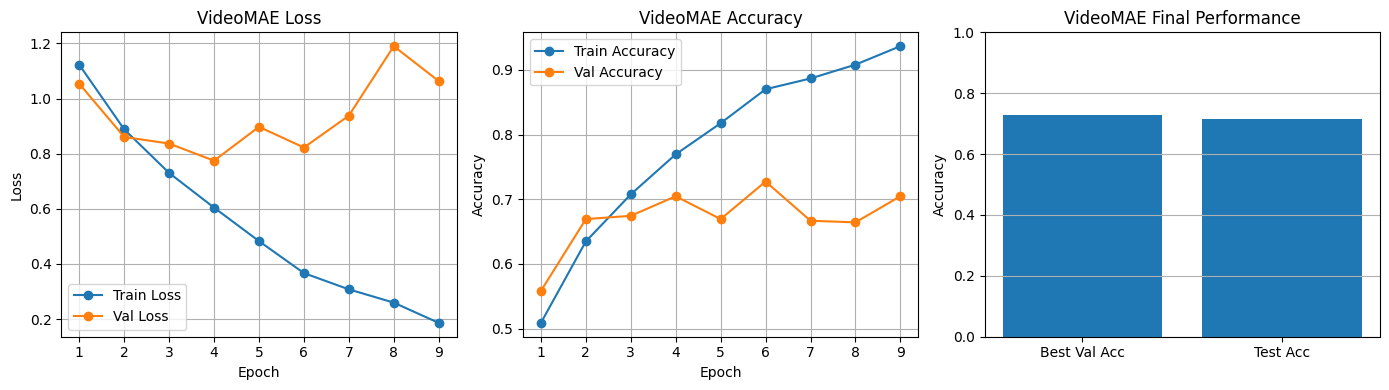

Graphs saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/outputs/videomae_graphs.png


<Figure size 640x480 with 0 Axes>

In [27]:
# Cell 28: VideoMAE training graphs + save figure

import matplotlib.pyplot as plt
import os

epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 4))

# 1) Loss graph
plt.subplot(1, 3, 1)
plt.plot(epochs_ran, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], marker="o", label="Val Loss")
plt.title("VideoMAE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# 2) Accuracy graph
plt.subplot(1, 3, 2)
plt.plot(epochs_ran, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs_ran, history["val_acc"], marker="o", label="Val Accuracy")
plt.title("VideoMAE Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# 3) Best Val vs Test Accuracy
plt.subplot(1, 3, 3)
best_val = max(history["val_acc"])
test_acc_value = test_acc
plt.bar(["Best Val Acc", "Test Acc"], [best_val, test_acc_value])
plt.title("VideoMAE Final Performance")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

save_path = "/content/drive/MyDrive/GM_Assignment2_TikHarm/outputs/videomae_graphs.png"
plt.savefig(save_path, bbox_inches="tight")
print("Graphs saved to:", save_path)